```
==============================
 ___  ___ _____ _   _ ___
/ __|/ __|_   _| | | | _ \
\__ \ (__  | | | |_| |  _/
|___/\___| |_|  \___/|_|
==============================
```

In [6]:
# pip install clickhouse-driver wordcloud matplotlib numpy
from clickhouse_driver import Client
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
from wordcloud import WordCloud

In [7]:
# Catppuccin Mocha palette
CATPPUCCIN_MOCHA = [
    "#f5e0dc",  # Rosewater
    "#f2cdcd",  # Flamingo
    "#f5c2e7",  # Pink
    "#cba6f7",  # Mauve
    "#f38ba8",  # Red
    "#eba0ac",  # Maroon
    "#fab387",  # Peach
    "#f9e2af",  # Yellow
    "#a6e3a1",  # Green
    "#94e2d5",  # Teal
    "#89dceb",  # Sky
    "#74c7ec",  # Sapphire
    "#89b4fa",  # Blue
    "#b4befe",  # Lavender
]
CATPPUCCIN_BASE = "#1e1e2e"   # Mocha base (background)

catppuccin_cmap = mcolors.LinearSegmentedColormap.from_list(
    "catppuccin_mocha", CATPPUCCIN_MOCHA
)

def catppuccin_color_func(word, font_size, position, orientation, random_state=None, **kwargs):
    color = CATPPUCCIN_MOCHA[random_state.randint(0, len(CATPPUCCIN_MOCHA) - 1)]
    return color

```
================================================
__    __  ___  ___  ___      ___  _     ___  _   _ ___ 
\ \  / / / _ \| _ \|   \    / __|| |   / _ \| | | |   \
 \ \/ / | (_) |   /| |) |  | (__ | |__| (_) | |_| | |) |
  \__/   \___/|_|_\|___/    \___||____|\___/ \___/ |___/
================================================
```

In [ ]:
# Query top 200 words from the gold model
client = Client(
    host="localhost",
    port=9100,
    user="clickhouse",
    password="clickhouse",
    database="analytics",
)

rows = client.execute(
    """
    SELECT word, word_count
    FROM analytics.gold_game_title_word_cloud
    ORDER BY word_count DESC
    LIMIT 200
    """
)

word_freq = {word: count for word, count in rows}

Fetched 200 words. Top 5: [('vr', 1978), ('edition', 1582), ('simulator', 1468), ('game', 1183), ('world', 855)]


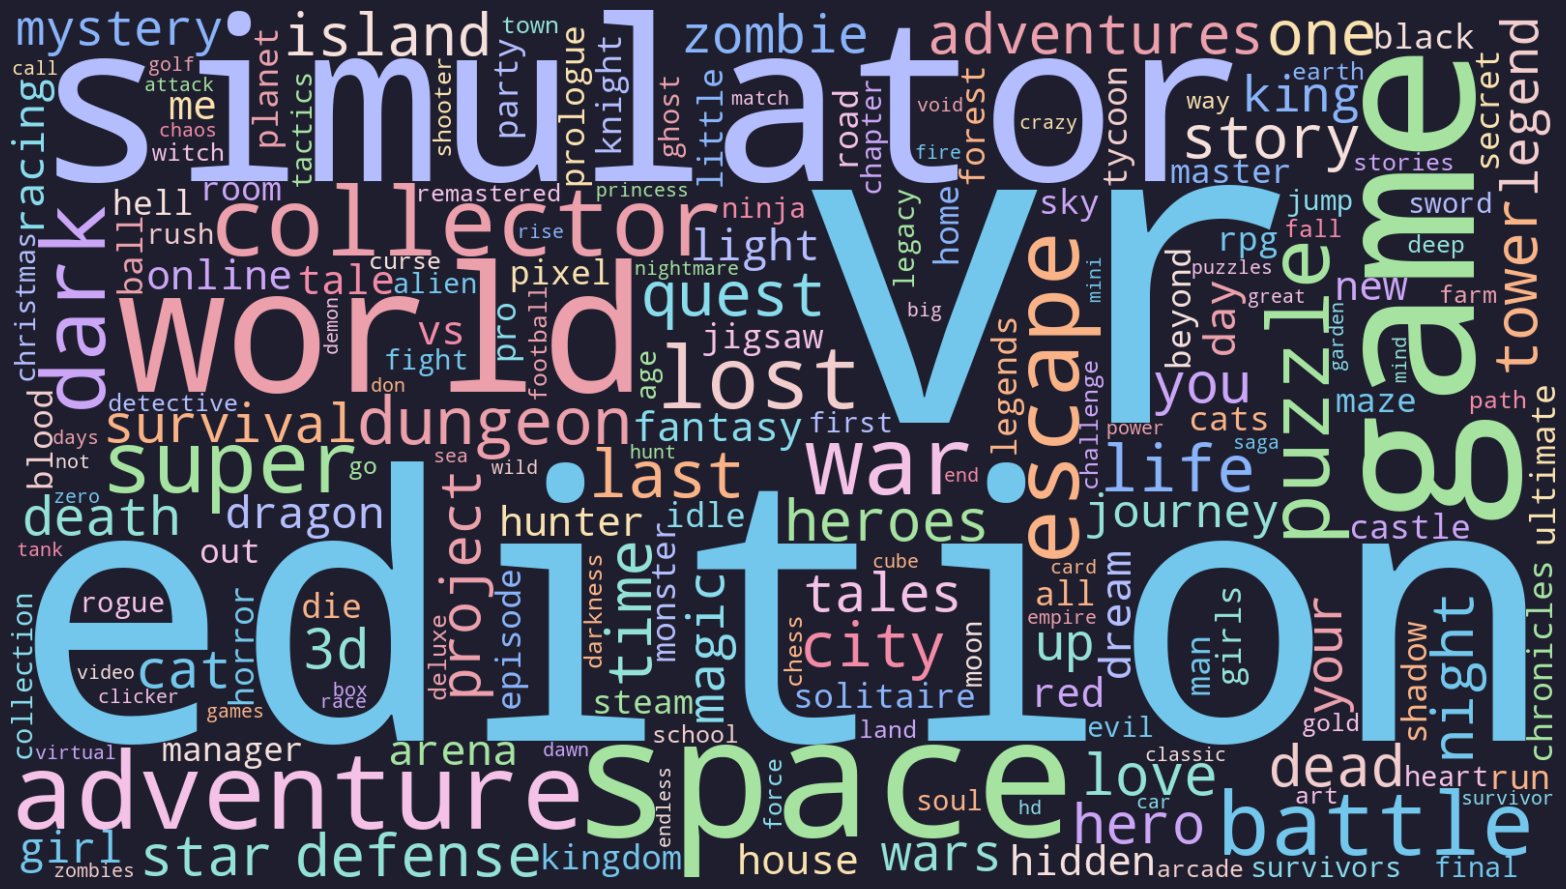

In [10]:
wc = WordCloud(
    width=1600,
    height=900,
    background_color=CATPPUCCIN_BASE,
    color_func=catppuccin_color_func,
    max_words=200,
    prefer_horizontal=0.8,
    relative_scaling=0.5,
).generate_from_frequencies(word_freq)

fig, ax = plt.subplots(figsize=(16, 9), facecolor=CATPPUCCIN_BASE)
ax.imshow(wc, interpolation="bilinear")
ax.axis("off")

plt.tight_layout()
plt.savefig("word_cloud.png", dpi=150, bbox_inches="tight", facecolor=CATPPUCCIN_BASE)
plt.show()